**Обучение LSTM-автоэнкодера**

**Этапы:**
1. Формирование скользящих окон (ЭЦН: 60×9, ШГН: 100×9) (Timestep × число признаков), а длительность окна в минутах берётся из спектрального анализа (ЭЦН: один цикл, ШГН: два цикла)
2. Обучение LSTM-автоэнкодера (encoder → latent space → decoder)

**Вход:**
- data/processed/ecn_train.csv, ecn_val.csv, ecn_test.csv, scaler_ecn.pkl
- data/processed/shgn_train.csv, shgn_val.csv, shgn_test.csv, scaler_shgn.pkl

**Важно:** Данные ШГН уже объединены (скважины 134+135) и нормализованы одним scaler'ом.

**Выход:**
- models/ecn/ (encoder.pth, decoder.pth, metadata.json, scaler.pkl)
- models/shgn/ (encoder.pth, decoder.pth, metadata.json, scaler.pkl)

In [ ]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

### 1: Загрузка данных из /data/processed

In [2]:
DATA_DIR = Path("../data/processed")
FEATURE_COLUMNS = [
    "us_center",
    "us_periph",
    "gas_center",
    "gas_periph",
    "temp",
    "water_center",
    "water_periph",
    "gas_integral",
    "water_integral",
]

In [3]:
df_ecn_train = pd.read_csv(DATA_DIR / "ecn_train.csv", parse_dates=["timestamp"])
df_ecn_val = pd.read_csv(DATA_DIR / "ecn_val.csv", parse_dates=["timestamp"])
df_ecn_test = pd.read_csv(DATA_DIR / "ecn_test.csv", parse_dates=["timestamp"])

df_shgn_train = pd.read_csv(DATA_DIR / "shgn_train.csv", parse_dates=["timestamp"])
df_shgn_val = pd.read_csv(DATA_DIR / "shgn_val.csv", parse_dates=["timestamp"])
df_shgn_test = pd.read_csv(DATA_DIR / "shgn_test.csv", parse_dates=["timestamp"])

In [4]:
with open(DATA_DIR / "scaler_ecn.pkl", "rb") as f:
    scaler_ecn = pickle.load(f)

with open(DATA_DIR / "scaler_shgn.pkl", "rb") as f:
    scaler_shgn = pickle.load(f)

In [5]:
print("\nЭЦН:")
print(f"  Train: {len(df_ecn_train):,} точек")
print(f"  Val:   {len(df_ecn_val):,} точек")
print(f"  Test:  {len(df_ecn_test):,} точек")

print("\nШГН (скважины 134+135 объединённые):")
print(f"  Train: {len(df_shgn_train):,} точек")
print(f"  Val:   {len(df_shgn_val):,} точек")
print(f"  Test:  {len(df_shgn_test):,} точек")

print(f"\nПризнаков: {len(FEATURE_COLUMNS)}")
print(f"Колонки: {list(df_ecn_train.columns)}")


ЭЦН:
  Train: 40,649 точек
  Val:   5,081 точек
  Test:  5,082 точек

ШГН (скважины 134+135 объединённые):
  Train: 103,078 точек
  Val:   12,885 точек
  Test:  12,885 точек

Признаков: 9
Колонки: ['us_center', 'us_periph', 'gas_center', 'gas_periph', 'temp', 'water_center', 'water_periph', 'outlet_num', 'gas_integral', 'water_integral', 'timestamp', 'well']


In [6]:
print("\nПроверка нормализации:")
print(
    f"ЭЦН train - mean: {df_ecn_train[FEATURE_COLUMNS].mean().mean():.3f}, std: {df_ecn_train[FEATURE_COLUMNS].std().mean():.3f}"
)
print(
    f"ШГН train - mean: {df_shgn_train[FEATURE_COLUMNS].mean().mean():.3f}, std: {df_shgn_train[FEATURE_COLUMNS].std().mean():.3f}"
)

print("\nПропуски:")
print(f"ЭЦН: {df_ecn_train[FEATURE_COLUMNS].isnull().sum().sum()}")
print(f"ШГН: {df_shgn_train[FEATURE_COLUMNS].isnull().sum().sum()}")


Проверка нормализации:
ЭЦН train - mean: -0.043, std: 1.028
ШГН train - mean: 0.019, std: 0.984

Пропуски:
ЭЦН: 0
ШГН: 0


### 2: Формирование скользящих окон

Преобразуем временные ряды в матрицы окон для обучения автоэнкодера.

Параметры:
- ЭЦН: окно 60 точек (10 минут), шаг 1 точка (10 сек)
- ШГН: окно 100 точек (16 минут, ~2 цикла по 7 мин), шаг 1 точка (10 сек)

Результат: матрицы 60×9 / 100×9 (время × параметры)

Для ЭЦН явной периодичности, сравнимой с циклом штангового насоса, по графикам временных рядов не наблюдается, поэтому спектральный анализ не выполнялся. Длину окна выбирали эмпирически: при слишком коротких окнах модель плохо различала нормальную работу и аномалии, при слишком длинных — росла размерность и время обучения без заметного улучшения качества реконструкции. В итоге выбрано окно 60 отсчётов (10 минут) как компромисс между объёмом контекста и сложностью модели.

Для ШГН был выполнен спектральный анализ по признакам water_center, gas_center, us_center, который показал доминирующие периоды 6–8 минут. На этой основе практическим путём выбрано окно 100 отсчётов (~16 минут), покрывающее 2 цикла работы.

In [54]:
WINDOW_SIZE_ECN = 60
WINDOW_SIZE_SHGN = 100
STEP = 1

def create_sliding_windows(df, feature_columns, window_size, step=1, well_col="well"):
    X = df[feature_columns].values

    well_ids = df[well_col].values if well_col in df.columns else None

    windows = []
    for i in range(0, len(X) - window_size + 1, step):
        if well_ids is not None:
            if len(set(well_ids[i : i + window_size])) > 1:
                continue

        windows.append(X[i : i + window_size])

    return np.array(windows)

In [55]:
print("Формирование окон ЭЦН (60×9)...")
X_ecn_train = create_sliding_windows(df_ecn_train, FEATURE_COLUMNS, WINDOW_SIZE_ECN, STEP)
X_ecn_val = create_sliding_windows(df_ecn_val, FEATURE_COLUMNS, WINDOW_SIZE_ECN, STEP)
X_ecn_test = create_sliding_windows(df_ecn_test, FEATURE_COLUMNS, WINDOW_SIZE_ECN, STEP)

print(f"  Train: {X_ecn_train.shape}")
print(f"  Val:   {X_ecn_val.shape}")
print(f"  Test:  {X_ecn_test.shape}")

print("\nФормирование окон ШГН (100×9)...")
X_shgn_train = create_sliding_windows(df_shgn_train, FEATURE_COLUMNS, WINDOW_SIZE_SHGN, STEP)
X_shgn_val = create_sliding_windows(df_shgn_val, FEATURE_COLUMNS, WINDOW_SIZE_SHGN, STEP)
X_shgn_test = create_sliding_windows(df_shgn_test, FEATURE_COLUMNS, WINDOW_SIZE_SHGN, STEP)

print(f"  Train: {X_shgn_train.shape}")
print(f"  Val:   {X_shgn_val.shape}")
print(f"  Test:  {X_shgn_test.shape}")

print("\nПроверка на аномалии:")
print(f"ЭЦН - NaN: {np.isnan(X_ecn_train).sum()}, Inf: {np.isinf(X_ecn_train).sum()}")
print(f"ШГН - NaN: {np.isnan(X_shgn_train).sum()}, Inf: {np.isinf(X_shgn_train).sum()}")

Формирование окон ЭЦН (60×9)...
  Train: (40590, 60, 9)
  Val:   (5022, 60, 9)
  Test:  (5023, 60, 9)

Формирование окон ШГН (100×9)...
  Train: (86320, 100, 9)
  Val:   (9898, 100, 9)
  Test:  (3271, 100, 9)

Проверка на аномалии:
ЭЦН - NaN: 0, Inf: 0
ШГН - NaN: 0, Inf: 0


In [56]:
def plot_random_window(X, feature_columns, window_size, pump_type):
    idx = np.random.randint(0, len(X))
    window = X[idx]

    _, axes = plt.subplots(3, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, col in enumerate(feature_columns):
        axes[i].plot(window[:, i])
        axes[i].set_title(col)
        axes[i].set_xlabel("Время (×10 сек)")
        axes[i].grid(True, alpha=0.3)

    plt.suptitle(f"{pump_type}: окно #{idx} ({window_size} точек = {window_size // 6} минут)")
    plt.tight_layout()
    plt.show()

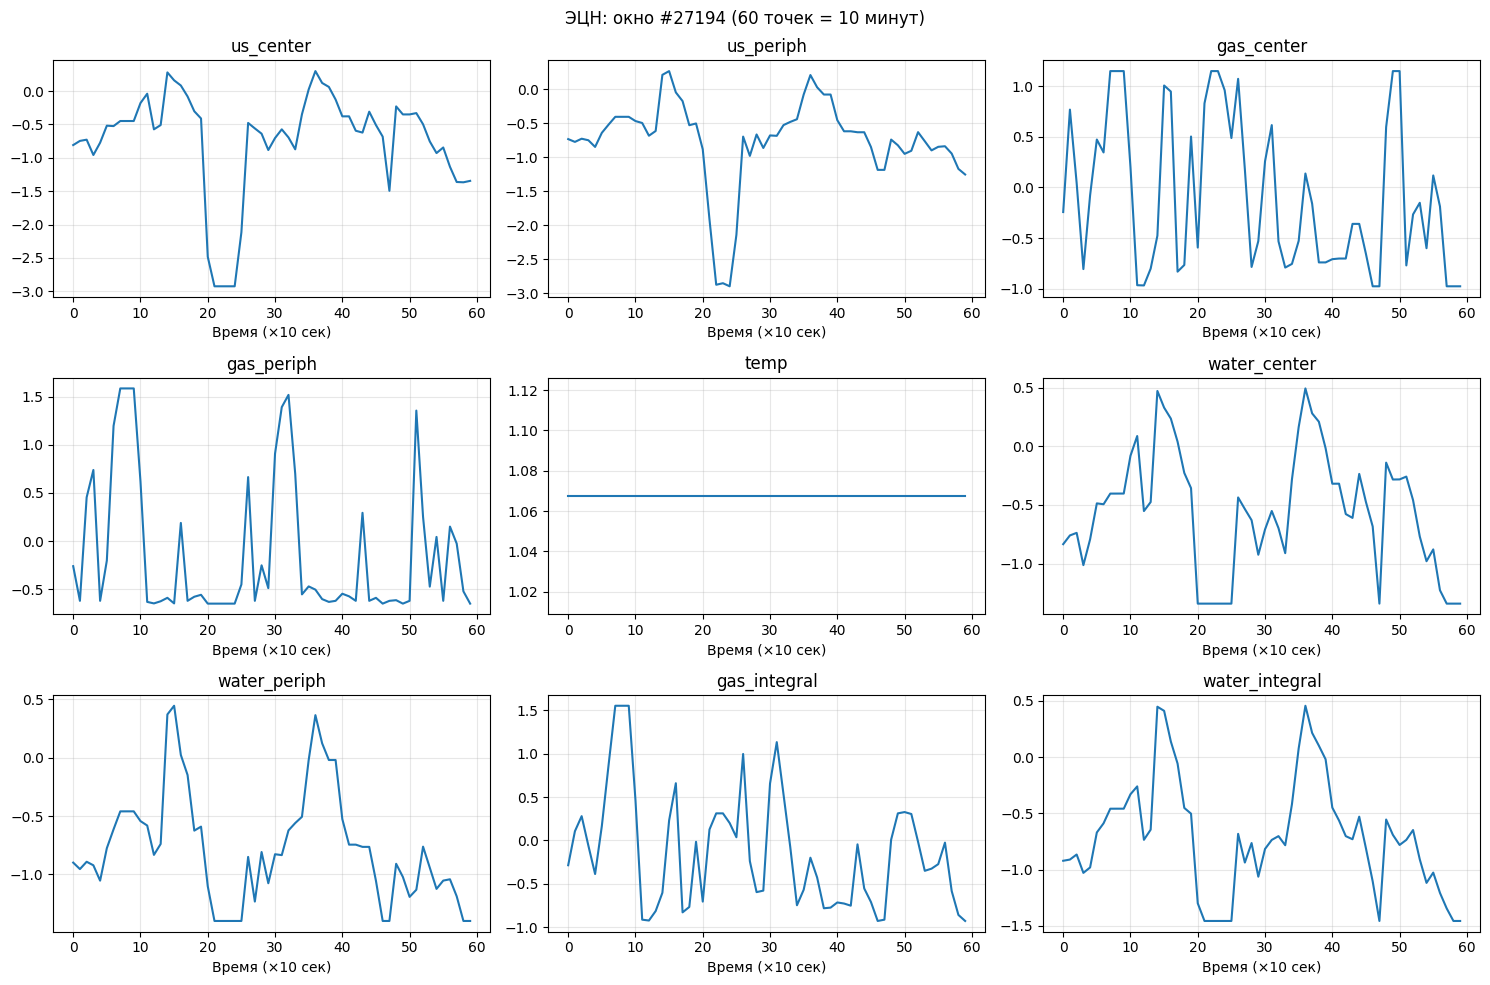

In [67]:
plot_random_window(X_ecn_train, FEATURE_COLUMNS, WINDOW_SIZE_ECN, "ЭЦН")

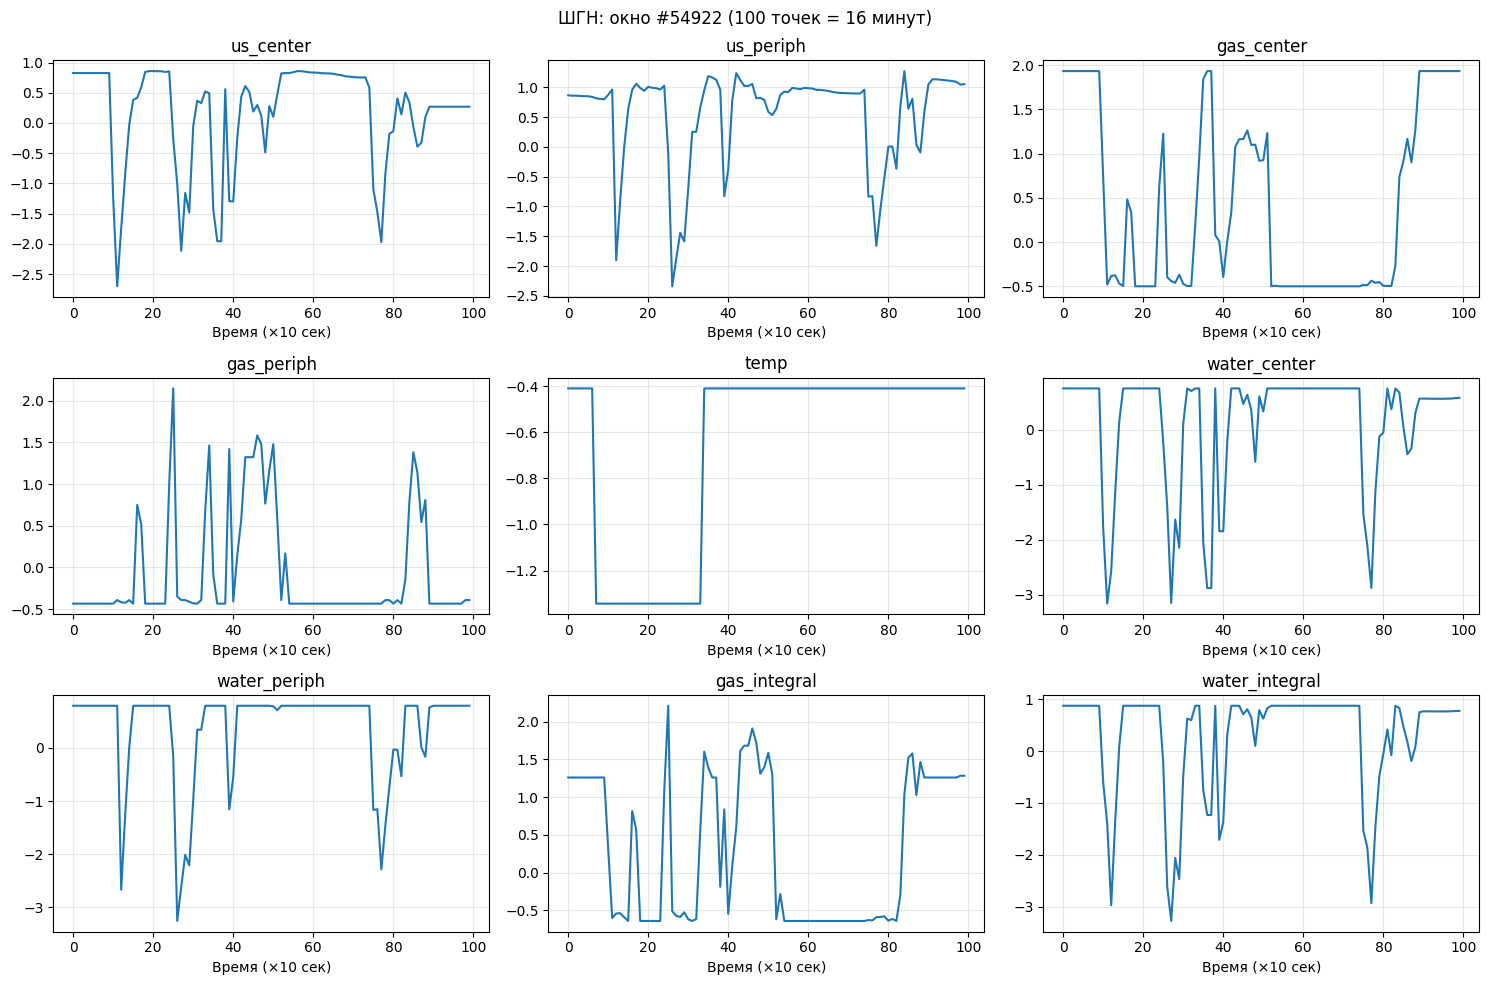

In [74]:
plot_random_window(X_shgn_train, FEATURE_COLUMNS, WINDOW_SIZE_SHGN, "ШГН")

### 3. Подготовка данных для PyTorch

In [ ]:
RANDOM_SEED = 42
BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N_EPOCHS = 50
LR = 1e-3
INPUT_SIZE = 9
LR_SCHEDULER_PATIENCE = 3
PATIENCE_EARLY_STOP = 10
WEIGHT_DECAY = 1e-5

HIDDEN_SIZE = 128
LATENT_DIMS = [4, 5, 6, 7]

TRAIN_FRACTION_FOR_SEARCH = 0.4

RNN_NUM_LAYERS = 2
RNN_DROPOUT = 0.2

TCN_NUM_LAYERS = 3
TCN_KERNEL_SIZE = 3
TCN_DILATION_BASE = 2
TCN_DROPOUT = 0.2

MAX_GRAD_NORM = 1.0

In [76]:
def make_dataloaders(X_train, X_val, X_test, batch_size=BATCH_SIZE):
    train_tensor = torch.from_numpy(X_train).float()
    val_tensor = torch.from_numpy(X_val).float()
    test_tensor = torch.from_numpy(X_test).float()

    train_ds = TensorDataset(train_tensor, train_tensor.clone())
    val_ds = TensorDataset(val_tensor, val_tensor.clone())
    test_ds = TensorDataset(test_tensor, test_tensor.clone())

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

    return train_loader, val_loader, test_loader

In [77]:
ecn_train_loader, ecn_val_loader, ecn_test_loader = make_dataloaders(X_ecn_train, X_ecn_val, X_ecn_test)

shgn_train_loader, shgn_val_loader, shgn_test_loader = make_dataloaders(X_shgn_train, X_shgn_val, X_shgn_test)

print("DataLoaders ЭЦН:")
for name, loader in [("train", ecn_train_loader), ("val", ecn_val_loader), ("test", ecn_test_loader)]:
    x, y = next(iter(loader))
    print(f"  {name}: batches={len(loader)}, batch_shape={x.shape}, target_shape={y.shape}")

print("\nDataLoaders ШГН:")
for name, loader in [("train", shgn_train_loader), ("val", shgn_val_loader), ("test", shgn_test_loader)]:
    x, y = next(iter(loader))
    print(f"  {name}: batches={len(loader)}, batch_shape={x.shape}, target_shape={y.shape}")

DataLoaders ЭЦН:
  train: batches=318, batch_shape=torch.Size([128, 60, 9]), target_shape=torch.Size([128, 60, 9])
  val: batches=40, batch_shape=torch.Size([128, 60, 9]), target_shape=torch.Size([128, 60, 9])
  test: batches=40, batch_shape=torch.Size([128, 60, 9]), target_shape=torch.Size([128, 60, 9])

DataLoaders ШГН:
  train: batches=675, batch_shape=torch.Size([128, 100, 9]), target_shape=torch.Size([128, 100, 9])
  val: batches=78, batch_shape=torch.Size([128, 100, 9]), target_shape=torch.Size([128, 100, 9])
  test: batches=26, batch_shape=torch.Size([128, 100, 9]), target_shape=torch.Size([128, 100, 9])


### 4. Сравнение архитектур автоэнкодеров

Для выбора архитектуры автоэнкодера используем единый протокол оценки:

- **Общие условия обучения**
  - одинаковая предобработка данных (окна 60×9 для ЭЦН и 100×9 для ШГН);
  - одинаковые train/val/test разбиения;
  - одинаковые базовые гиперпараметры: размер латентного пространства, размер скрытого слоя, оптимизатор (Adam), скорость обучения, размер батча и число эпох.

- **Основной критерий**
  - средняя ошибка реконструкции на валидационной выборке (**val MSE**):
    - на train обучаем модель восстанавливать окно «само из себя»;
    - на val считаем средний MSE по всем окнам;
    - лучшая архитектура — та, у которой минимальный `val_loss` при сопоставимой сложности сети.

- **Дополнительный анализ**
  - сравнение динамики `train_loss` / `val_loss` по эпохам (раннее переобучение = архитектура неудачна);
  - сравнение распределения ошибки реконструкции для train и val (гистограммы / KDE): хорошая модель даёт близкие распределения без «длинных хвостов» на val.

В сравнении участвуют три архитектуры:

1. **LSTM‑автоэнкодер**  
   - последовательно кодирует окно LSTM‑слоями в латентный вектор фиксированной размерности;  
   - декодер — LSTM, восстанавливающий исходную последовательность по латентному представлению.

2. **GRU‑автоэнкодер**  
   - архитектурно аналогичен LSTM‑автоэнкодеру, но использует GRU‑ячейки (меньше параметров и быстрее обучение);  
   - обучается и оценивается в тех же условиях, что и LSTM‑модель.

3. **TCN‑автоэнкодер (Temporal Convolutional Network)**  
   - энкодер — несколько 1D‑сверточных слоёв с дилатацией (TCN), обрабатывающих последовательность по времени и сжимающих её в латентный вектор;  
   - декодер — обратная TCN‑структура (транспонированные/обычные свёртки с upsampling), восстанавливающая временной ряд.

Все архитектуры используют **одно и то же размерность латентного пространства и одинаковые базовые гиперпараметры** на этапе сравнения. После выбора лучшей архитектуры её гиперпараметры могут быть дополнительно уточнены (tuning) и финальная модель дообучается на полном тренировочном наборе.

In [78]:
def subsample_windows(X, fraction, seed=RANDOM_SEED):
    n = X.shape[0]
    n_sub = max(1, int(n * fraction))

    rng = np.random.default_rng(seed)
    indices = rng.choice(n, size=n_sub, replace=False)
    indices = np.sort(indices)

    return X[indices]

In [ ]:
X_ecn_train_sub = subsample_windows(X_ecn_train, TRAIN_FRACTION_FOR_SEARCH)
X_shgn_train_sub = subsample_windows(X_shgn_train, TRAIN_FRACTION_FOR_SEARCH)

ecn_train_loader_sub, ecn_val_loader_sub, _ = make_dataloaders(X_ecn_train_sub, X_ecn_val, X_ecn_test)
shgn_train_loader_sub, shgn_val_loader_sub, _ = make_dataloaders(X_shgn_train_sub, X_shgn_val, X_shgn_test)

**LSTM‑автоэнкодер.**  
Входное окно размерности (T=60/100, F=9) подаётся в LSTM‑энкодер.  
Последнее скрытое состояние LSTM сжимается полносвязным слоем в латентный вектор фиксированной размерности `latent_dim`.  
Декодер получает этот латентный вектор, повторённый для каждого шага времени, проецирует его в пространство скрытого состояния и восстанавливает последовательность через LSTM‑слои. К выходу каждого шага применяется линейный слой для реконструкции признаков. Таким образом, модель учится кодировать окно во вектор и восстанавливать его обратно.

**GRU‑автоэнкодер.**  
Архитектура полностью аналогична LSTM‑автоэнкодеру, но в качестве рекуррентных ячеек используются GRU.  
Это уменьшает число параметров и ускоряет обучение при сохранении способности моделировать временные зависимости.  
Как и в LSTM‑варианте, энкодер GRU сжимает окно в латентный вектор, а декодер GRU восстанавливает последовательность из повторённого латентного представления.

**TCN‑автоэнкодер (Temporal Convolutional Network).**  
Этот вариант обрабатывает окно как временной сигнал, используя 1D‑свёртки по времени.  
В энкодере несколько свёрточных слоёв с дилатацией, которые «смотрят» на всё более длинные отрезки временного ряда. Получившийся набор свёрточных признаков сжимается в компактное латентное представление.  
Декодер использует транспонированные свёртки (conv transpose) или upsampling + свёртки для восстановления исходной временной размерности. На выходе получаем окно той же длины, что и на входе.

In [83]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_size, latent_dim, seq_len, num_layers=RNN_NUM_LAYERS):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_size = hidden_size
        self.latent_dim = latent_dim
        self.seq_len = seq_len
        self.num_layers = num_layers

        self.encoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=RNN_DROPOUT if num_layers > 1 else 0.0,
        )
        self.fc_enc = nn.Linear(hidden_size, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, hidden_size)
        self.decoder_lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=RNN_DROPOUT if num_layers > 1 else 0.0,
        )
        self.output_layer = nn.Linear(hidden_size, input_dim)

    def encode(self, x):
        _, (h_n, _) = self.encoder_lstm(x)
        h_last = h_n[-1]
        z = self.fc_enc(h_last)
        return z

    def decode(self, z, seq_len=None):
        if seq_len is None:
            seq_len = self.seq_len

        B = z.size(0)
        device = z.device

        z_repeated = z.unsqueeze(1).repeat(1, seq_len, 1)
        dec_input = self.fc_dec(z_repeated)

        h0 = torch.zeros(self.num_layers, B, self.hidden_size, device=device)
        c0 = torch.zeros(self.num_layers, B, self.hidden_size, device=device)

        dec_output, _ = self.decoder_lstm(dec_input, (h0, c0))
        recon = self.output_layer(dec_output)
        return recon

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z, seq_len=x.size(1))
        return recon

In [84]:
class GRUAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_size, latent_dim, seq_len, num_layers=RNN_NUM_LAYERS):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_size = hidden_size
        self.latent_dim = latent_dim
        self.seq_len = seq_len
        self.num_layers = num_layers

        self.encoder_gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=RNN_DROPOUT if num_layers > 1 else 0.0,
        )
        self.fc_enc = nn.Linear(hidden_size, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, hidden_size)
        self.decoder_gru = nn.GRU(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=RNN_DROPOUT if num_layers > 1 else 0.0,
        )
        self.output_layer = nn.Linear(hidden_size, input_dim)

    def encode(self, x):
        _, h_n = self.encoder_gru(x)
        h_last = h_n[-1]
        z = self.fc_enc(h_last)
        return z

    def decode(self, z, seq_len=None):
        if seq_len is None:
            seq_len = self.seq_len

        B = z.size(0)
        device = z.device

        z_repeated = z.unsqueeze(1).repeat(1, seq_len, 1)
        dec_input = self.fc_dec(z_repeated)

        h0 = torch.zeros(self.num_layers, B, self.hidden_size, device=device)

        dec_output, _ = self.decoder_gru(dec_input, h0)
        recon = self.output_layer(dec_output)
        return recon

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z, seq_len=x.size(1))
        return recon

In [85]:
class CausalConv1d(nn.Conv1d):
    def forward(self, x):
        pad = (self.kernel_size[0] - 1) * self.dilation[0]
        x = F.pad(x, (pad, 0))
        return super().forward(x)


class TemporalBlock(nn.Module):
    def __init__(self, n_in, n_out, kernel_size, stride, dilation, dropout=0.2):
        super().__init__()
        self.conv1 = CausalConv1d(n_in, n_out, kernel_size, stride=stride, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(n_out)
        self.act1 = nn.PReLU(num_parameters=n_out)
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = CausalConv1d(n_out, n_out, kernel_size, stride=stride, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(n_out)
        self.act2 = nn.PReLU(num_parameters=n_out)
        self.drop2 = nn.Dropout(dropout)

        self.downsample = nn.Conv1d(n_in, n_out, 1) if n_in != n_out else None
        self.final_act = nn.PReLU(num_parameters=n_out)

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_normal_(self.conv1.weight, mode="fan_in", nonlinearity="linear")
        nn.init.kaiming_normal_(self.conv2.weight, mode="fan_in", nonlinearity="linear")

    def forward(self, x):
        res = x if self.downsample is None else self.downsample(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.act1(out)
        out = self.drop1(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.act2(out)
        out = self.drop2(out)
        return self.final_act(out + res)

In [91]:
class TCNAutoencoder(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_size,
        latent_dim,
        seq_len,
        num_layers=TCN_NUM_LAYERS,
        kernel_size=TCN_KERNEL_SIZE,
        dilation_base=TCN_DILATION_BASE,
        dropout=TCN_DROPOUT,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_size = hidden_size
        self.latent_dim = latent_dim
        self.seq_len = seq_len
        self.num_layers = num_layers

        hidden_channels = [hidden_size] * num_layers
        enc_layers = []
        for i, ch in enumerate(hidden_channels):
            n_in = input_dim if i == 0 else hidden_channels[i - 1]
            dilation = dilation_base**i
            enc_layers.append(TemporalBlock(n_in, ch, kernel_size, 1, dilation, dropout))
        self.encoder = nn.Sequential(*enc_layers)

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc_enc = nn.Linear(hidden_channels[-1], latent_dim)

        self.fc_dec = nn.Linear(latent_dim, hidden_size * seq_len)

        dec_layers = []
        dec_channels = list(reversed(hidden_channels))
        for i in range(num_layers):
            n_in = dec_channels[0] if i == 0 else dec_channels[i - 1]
            n_out = dec_channels[i]
            dilation = dilation_base ** (num_layers - 1 - i)
            dec_layers.append(TemporalBlock(n_in, n_out, kernel_size, 1, dilation, dropout))
        self.decoder = nn.Sequential(*dec_layers)
        self.recon_layer = nn.Conv1d(hidden_size, input_dim, kernel_size=1)

    def encode(self, x):
        x = x.transpose(1, 2)
        feat = self.encoder(x)
        pooled = self.global_pool(feat).squeeze(-1)
        return self.fc_enc(pooled)

    def decode(self, z, seq_len=None):
        if seq_len is None:
            seq_len = self.seq_len
        B = z.size(0)
        h = self.fc_dec(z).view(B, self.hidden_size, seq_len)
        dec_feat = self.decoder(h)
        recon = self.recon_layer(dec_feat)
        return recon.transpose(1, 2)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z, x.size(1))

In [92]:
def train_epoch(model, train_loader, optimizer, criterion, grad_clip_norm, device):
    model.train()

    total_loss = 0
    total_samples = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        batch_size = batch_x.size(0)

        optimizer.zero_grad()

        reconstructed = model(batch_x)

        loss = criterion(reconstructed, batch_y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)

        optimizer.step()

        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples

In [93]:
def validate(model, val_loader, criterion, device):
    model.eval()

    total_loss = 0
    total_samples = 0
    mse_per_feature = 0

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            batch_size = batch_x.size(0)

            reconstructed = model(batch_x)

            loss = criterion(reconstructed, batch_y)
            total_loss += loss.item() * batch_size

            mse_batch = ((reconstructed - batch_y) ** 2).mean(dim=(0, 1))
            mse_per_feature += mse_batch * batch_size

            total_samples += batch_size

    mse_per_feature /= total_samples
    return total_loss / total_samples, mse_per_feature.cpu().numpy()

In [94]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    lr,
    weight_decay,
    patience_lr,
    patience_early_stop,
    grad_clip_norm,
    device,
    save_path=None,
):
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=patience_lr, min_lr=1e-6
    )

    best_val_loss = float("inf")
    best_mse_per_feature = None
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "lr": []}

    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, grad_clip_norm, device)
        val_loss, mse_per_feature = validate(model, val_loader, criterion, device)

        current_lr = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(current_lr)

        print(
            f"Эпоха {epoch + 1}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | LR: {current_lr:.6f}"
        )

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_mse_per_feature = mse_per_feature
            patience_counter = 0
            if save_path:
                torch.save(
                    {
                        "model_state": model.state_dict(),
                        "config": {
                            "input_dim": model.input_dim,
                            "hidden_size": model.hidden_size,
                            "latent_dim": model.latent_dim,
                            "seq_len": model.seq_len,
                            "num_layers": model.num_layers,
                            "model_type": model.__class__.__name__,
                        },
                    },
                    save_path / "best_model.pth",
                )
        else:
            patience_counter += 1

        if patience_counter >= patience_early_stop:
            print(f"Early stopping на эпохе {epoch + 1}")
            break

    return best_val_loss, best_mse_per_feature, history

In [ ]:
def elbow_method(train_loader, val_loader, latent_dims, seq_len, pump_type, device, model_class=LSTMAutoencoder):
    results = []
    best_loss = float("inf")
    best_idx = -1

    for i, latent_dim in enumerate(latent_dims):
        print(f"\n{'=' * 70}")
        print(f"{pump_type}: Обучение с latent_dim = {latent_dim}")
        print(f"{'=' * 70}")

        model = model_class(
            input_dim=INPUT_SIZE,
            hidden_size=HIDDEN_SIZE,
            latent_dim=latent_dim,
            seq_len=seq_len,
        ).to(device)

        best_val_loss, best_mse_per_feature, history = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=N_EPOCHS,
            lr=LR,
            weight_decay=WEIGHT_DECAY,
            patience_lr=LR_SCHEDULER_PATIENCE,
            patience_early_stop=PATIENCE_EARLY_STOP,
            grad_clip_norm=MAX_GRAD_NORM,
            device=device,
            save_path=None,
        )

        results.append(
            {
                "latent_dim": latent_dim,
                "best_val_loss": best_val_loss,
                "mse_per_feature": best_mse_per_feature,
                "model": model,
                "history": history,
            }
        )

        if best_val_loss < best_loss:
            best_loss = best_val_loss
            best_idx = i

        print(f"\nЛучший val_loss: {best_val_loss:.6f}")

    print(f"\n{'=' * 60}")
    print(f"Лучшая модель: latent_dim={results[best_idx]['latent_dim']} (val_loss={best_loss:.6f})")
    print(f"{'=' * 60}")

    return results, results[best_idx]

In [96]:
def plot_elbow_results(results, pump_type):
    latent_dims = [r["latent_dim"] for r in results]
    val_losses = [r["best_val_loss"] for r in results]

    _, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(latent_dims, val_losses, marker="o", linewidth=2, markersize=8)
    axes[0].set_xlabel("Latent Dimension")
    axes[0].set_ylabel("Best Val Loss (MSE)")
    axes[0].set_title(f"{pump_type}: Elbow Method")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(latent_dims)

    mse_per_feature_all = [r["mse_per_feature"] for r in results]
    for i, feature in enumerate(FEATURE_COLUMNS):
        mse_values = [mse[i] for mse in mse_per_feature_all]
        axes[1].plot(latent_dims, mse_values, marker="o", label=feature)

    axes[1].set_xlabel("Latent Dimension")
    axes[1].set_ylabel("MSE по признакам")
    axes[1].set_title(f"{pump_type}: MSE по каждому признаку")
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(latent_dims)

    plt.tight_layout()
    plt.show()

In [97]:
def plot_reconstruction_comparison(results, X_val, pump_type, device, best_result=None):
    idx = np.random.randint(0, len(X_val))
    sample = torch.FloatTensor(X_val[idx : idx + 1]).to(device)

    reconstructions = []
    for result in results:
        model = result["model"]
        model.eval()

        with torch.no_grad():
            reconstructed = model(sample)

        reconstructions.append(
            {
                "latent_dim": result["latent_dim"],
                "reconstructed": reconstructed[0].cpu().numpy(),
                "is_best": best_result is not None and result["latent_dim"] == best_result["latent_dim"],
            }
        )

    _, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()

    for i, feature in enumerate(FEATURE_COLUMNS):
        axes[i].plot(sample[0, :, i].cpu().numpy(), label="Оригинал", linewidth=2, color="black")

        for recon in reconstructions:
            alpha = 1.0 if recon["is_best"] else 0.5
            linewidth = 2.5 if recon["is_best"] else 1.5
            linestyle = "-" if recon["is_best"] else "--"
            label = f"latent_dim={recon['latent_dim']}" + (" (лучшая)" if recon["is_best"] else "")

            axes[i].plot(
                recon["reconstructed"][:, i], label=label, linestyle=linestyle, alpha=alpha, linewidth=linewidth
            )

        axes[i].set_title(feature)
        axes[i].set_xlabel("Время (×10 сек)")
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)

    plt.suptitle(f"{pump_type}: Сравнение reconstruction для окна #{idx}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [99]:
def compare_all_architectures(train_loader, val_loader, seq_len, pump_type, device):
    architectures = {
        "LSTM": LSTMAutoencoder,
        "GRU": GRUAutoencoder,
        "TCN": TCNAutoencoder,
    }

    all_results = {}

    for name, model_class in architectures.items():
        print(f"\n{'=' * 70}")
        print(f"Сравнение архитектуры: {name}")
        print(f"{'=' * 70}")

        results, best = elbow_method(
            train_loader, val_loader, LATENT_DIMS, seq_len, f"{pump_type}-{name}", device, model_class
        )
        all_results[name] = {"results": results, "best": best}

    best_arch = min(all_results, key=lambda x: all_results[x]["best"]["best_val_loss"])
    print(f"\n{'=' * 70}")
    print(f"Лучшая архитектура: {best_arch}")
    print(f"Val loss: {all_results[best_arch]['best']['best_val_loss']:.6f}")
    print(f"Latent dim: {all_results[best_arch]['best']['latent_dim']}")
    print(f"{'=' * 70}")

    return all_results, best_arch

In [103]:
ecn_arch_results, ecn_best_arch_name = compare_all_architectures(
    ecn_train_loader_sub, ecn_val_loader, WINDOW_SIZE_ECN, "ЭЦН", DEVICE
)


Сравнение архитектуры: LSTM

ЭЦН-LSTM: Обучение с latent_dim = 3
Эпоха 1/30 | Train Loss: 1.069552 | Val Loss: 0.796589 | LR: 0.000100
Эпоха 2/30 | Train Loss: 0.818181 | Val Loss: 0.588570 | LR: 0.000100
Эпоха 3/30 | Train Loss: 0.613594 | Val Loss: 0.516741 | LR: 0.000100
Эпоха 4/30 | Train Loss: 0.554247 | Val Loss: 0.462499 | LR: 0.000100
Эпоха 5/30 | Train Loss: 0.481876 | Val Loss: 0.390911 | LR: 0.000100
Эпоха 6/30 | Train Loss: 0.406904 | Val Loss: 0.366436 | LR: 0.000100
Эпоха 7/30 | Train Loss: 0.368150 | Val Loss: 0.353152 | LR: 0.000100
Эпоха 8/30 | Train Loss: 0.346371 | Val Loss: 0.348111 | LR: 0.000100
Эпоха 9/30 | Train Loss: 0.327168 | Val Loss: 0.336634 | LR: 0.000100
Эпоха 10/30 | Train Loss: 0.301792 | Val Loss: 0.320281 | LR: 0.000100
Эпоха 11/30 | Train Loss: 0.279721 | Val Loss: 0.314671 | LR: 0.000100
Эпоха 12/30 | Train Loss: 0.266826 | Val Loss: 0.314051 | LR: 0.000100
Эпоха 13/30 | Train Loss: 0.257828 | Val Loss: 0.309660 | LR: 0.000100
Эпоха 14/30 | Train 

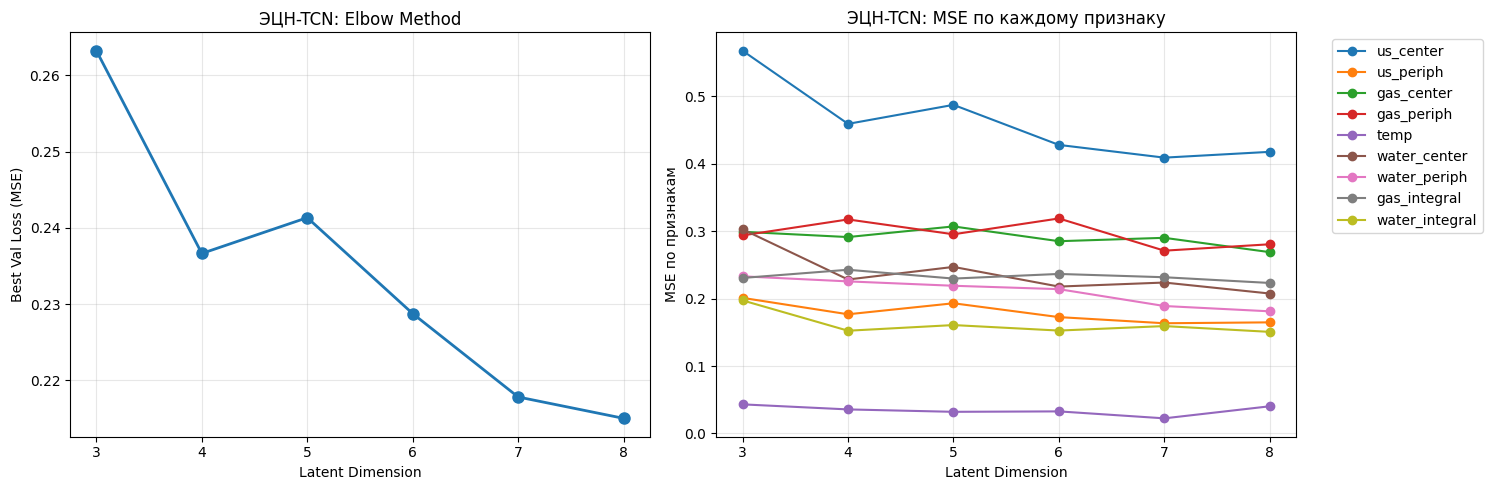

In [104]:
ecn_best_overall = ecn_arch_results[ecn_best_arch_name]["best"]
plot_elbow_results(ecn_arch_results[ecn_best_arch_name]["results"], f"ЭЦН-{ecn_best_arch_name}")

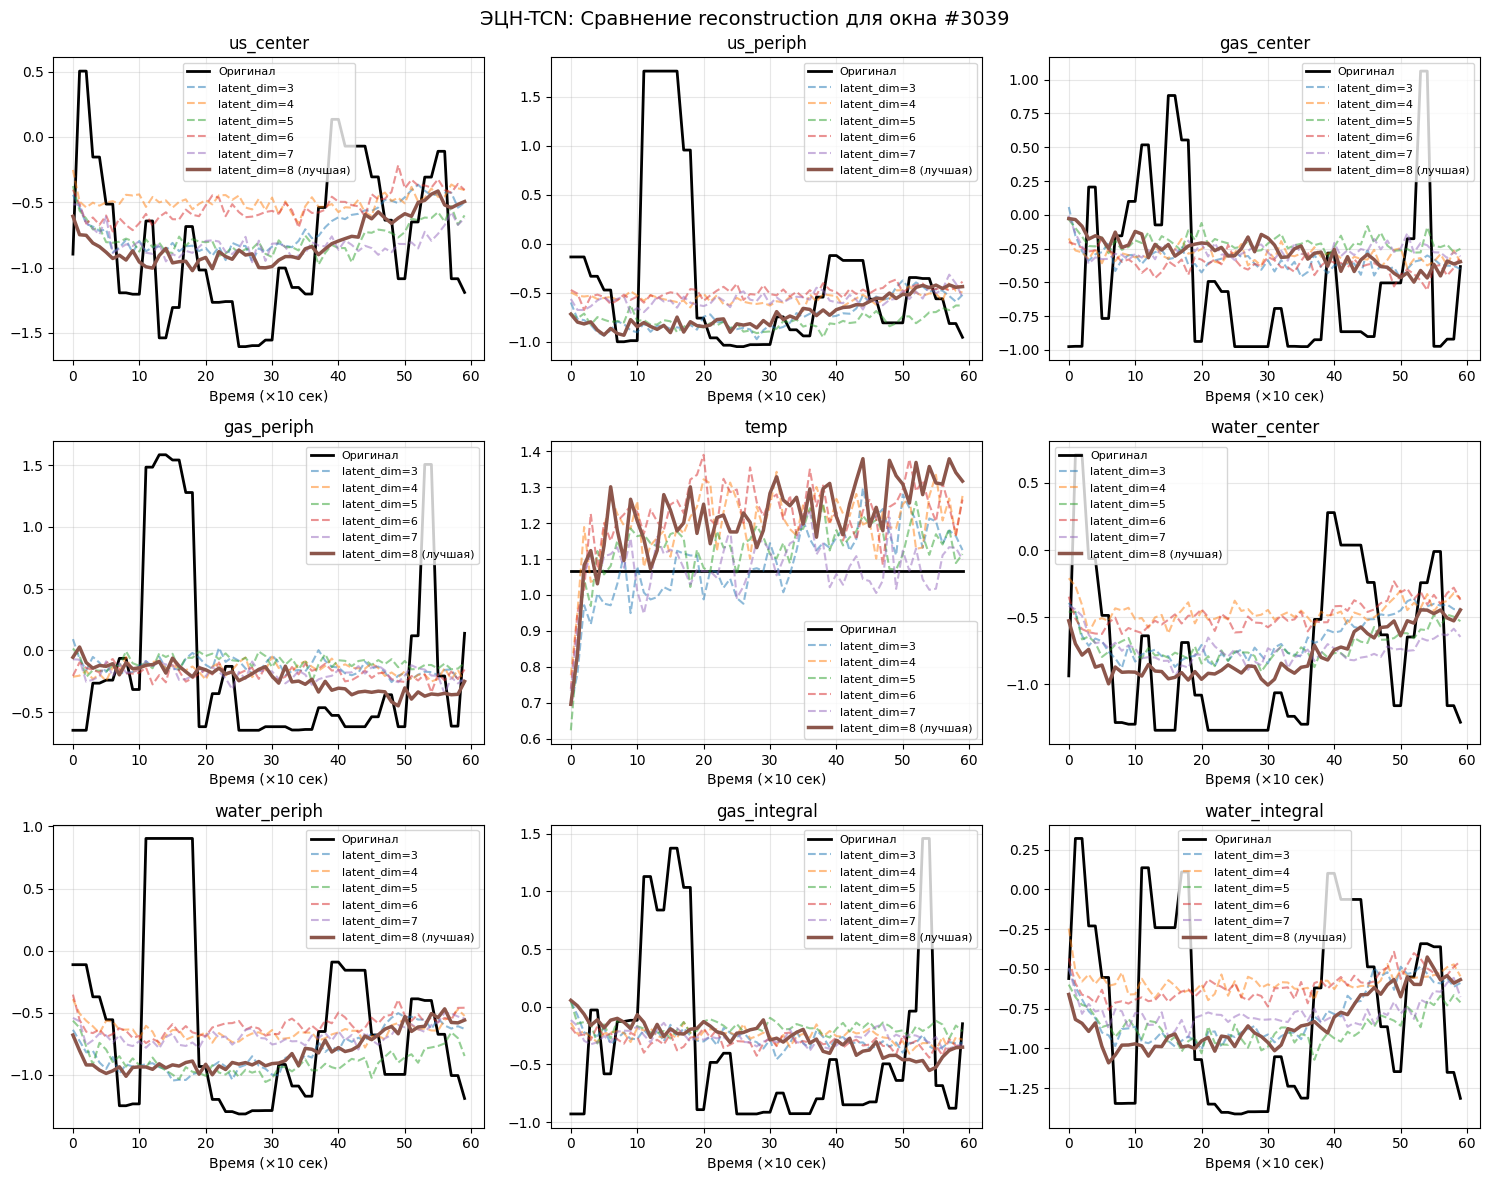

In [107]:
plot_reconstruction_comparison(
    ecn_arch_results[ecn_best_arch_name]["results"], X_ecn_val, f"ЭЦН-{ecn_best_arch_name}", DEVICE, ecn_best_overall
)

In [108]:
shgn_arch_results, shgn_best_arch_name = compare_all_architectures(
    shgn_train_loader_sub, shgn_val_loader, WINDOW_SIZE_SHGN, "ШГН", DEVICE
)


Сравнение архитектуры: LSTM

ШГН-LSTM: Обучение с latent_dim = 3
Эпоха 1/30 | Train Loss: 0.936864 | Val Loss: 1.028222 | LR: 0.000100
Эпоха 2/30 | Train Loss: 0.842121 | Val Loss: 1.004705 | LR: 0.000100
Эпоха 3/30 | Train Loss: 0.810347 | Val Loss: 0.990689 | LR: 0.000100
Эпоха 4/30 | Train Loss: 0.799557 | Val Loss: 0.985273 | LR: 0.000100
Эпоха 5/30 | Train Loss: 0.795200 | Val Loss: 0.984546 | LR: 0.000100
Эпоха 6/30 | Train Loss: 0.793416 | Val Loss: 0.982936 | LR: 0.000100
Эпоха 7/30 | Train Loss: 0.791950 | Val Loss: 0.984881 | LR: 0.000100
Эпоха 8/30 | Train Loss: 0.789203 | Val Loss: 0.982723 | LR: 0.000100
Эпоха 9/30 | Train Loss: 0.786714 | Val Loss: 0.979740 | LR: 0.000100
Эпоха 10/30 | Train Loss: 0.785451 | Val Loss: 0.979286 | LR: 0.000100
Эпоха 11/30 | Train Loss: 0.784266 | Val Loss: 0.977874 | LR: 0.000100
Эпоха 12/30 | Train Loss: 0.783154 | Val Loss: 0.976115 | LR: 0.000100
Эпоха 13/30 | Train Loss: 0.781393 | Val Loss: 0.974542 | LR: 0.000100
Эпоха 14/30 | Train 

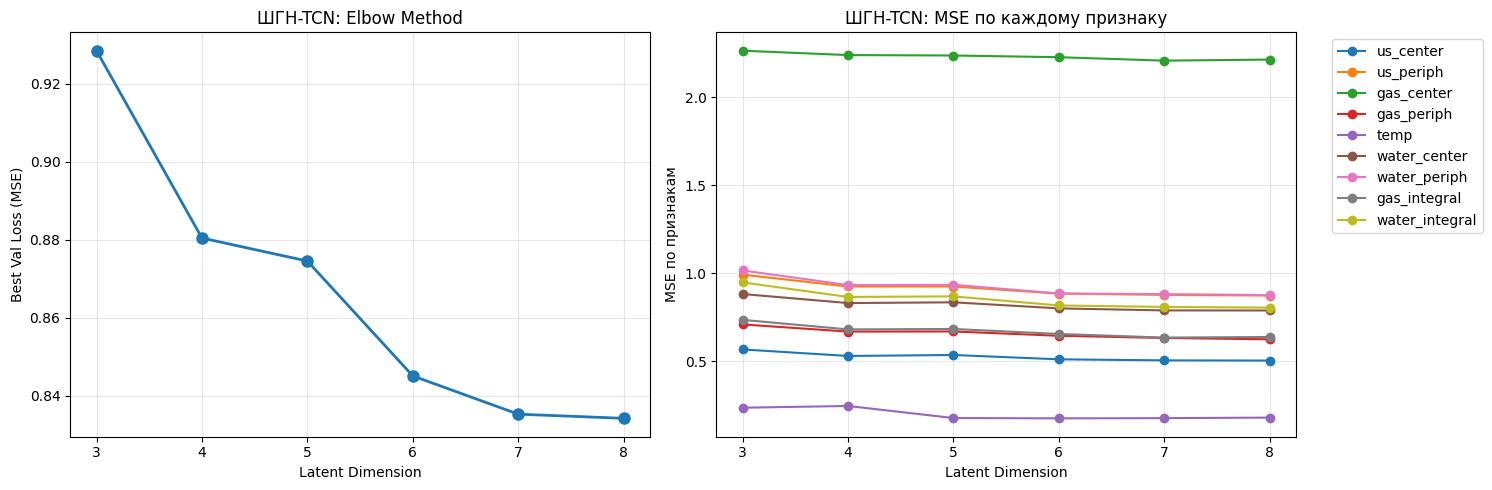

In [109]:
shgn_best_overall = shgn_arch_results[shgn_best_arch_name]["best"]
plot_elbow_results(shgn_arch_results[shgn_best_arch_name]["results"], f"ШГН-{shgn_best_arch_name}")

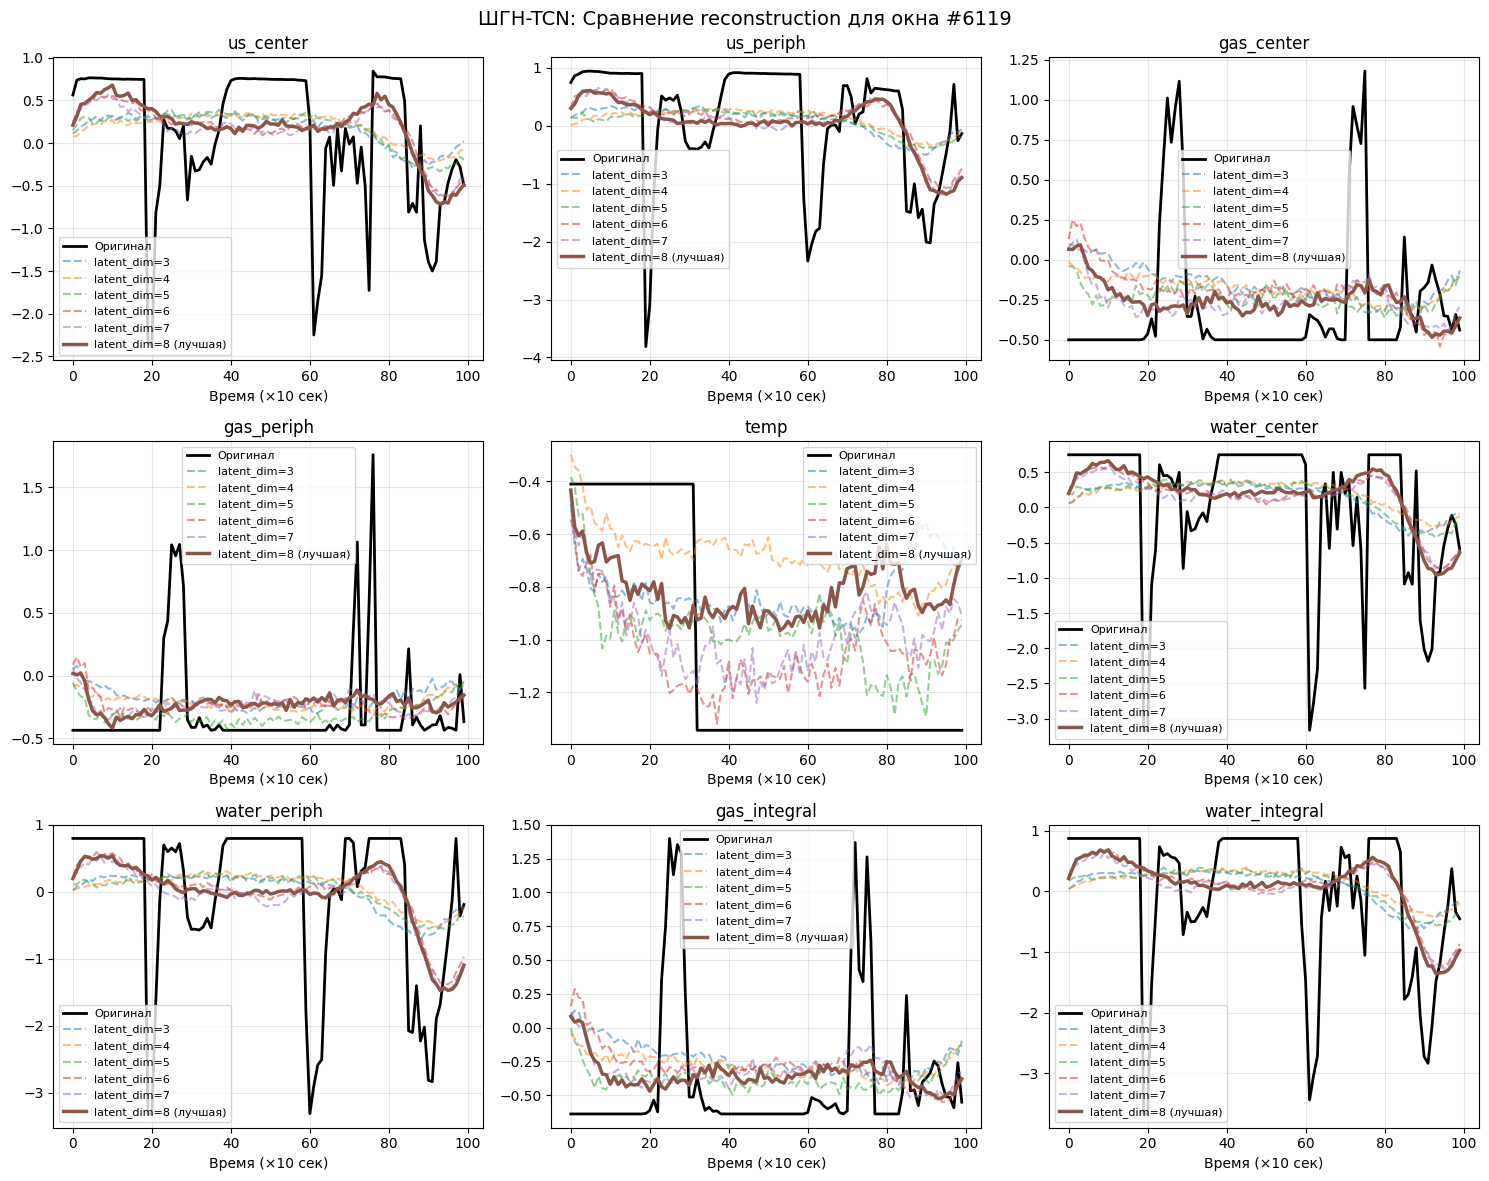

In [110]:
plot_reconstruction_comparison(
    shgn_arch_results[shgn_best_arch_name]["results"],
    X_shgn_val,
    f"ШГН-{shgn_best_arch_name}",
    DEVICE,
    shgn_best_overall,
)

In [112]:
print(
    f"ЭЦН:  лучшая архитектура = {ecn_best_arch_name}, latent_dim = {ecn_best_overall['latent_dim']}, val_loss = {ecn_best_overall['best_val_loss']:.6f}"
)
print(
    f"ШГН:  лучшая архитектура = {shgn_best_arch_name}, latent_dim = {shgn_best_overall['latent_dim']}, val_loss = {shgn_best_overall['best_val_loss']:.6f}"
)

ЭЦН:  лучшая архитектура = TCN, latent_dim = 8, val_loss = 0.215029
ШГН:  лучшая архитектура = TCN, latent_dim = 8, val_loss = 0.834234
